In [33]:
# %%
# Importações básicas
import sys
import os

sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchdiffeq import odeint

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import orthogonal_mp_gram
from sklearn.metrics import r2_score

import node_v4
from node_v4 import carregar_experimento, processar_dataset

device = node_v4.device
print(f"Utilizando device: {device}")

Utilizando device: cpu


In [34]:
# %%
# 1. Carregamento dos Datasets
BASE2 = "https://raw.githubusercontent.com/FelipeEduardoMarcondes/SYSTEM-IDENTIFICATION-AERO/main/experimentos/"

train_files = [
    "aprbs-1_0827_17-19.csv", "aprbs-2_0827_17-25.csv", "aprbs-3_0827_17-28.csv",
    "multi-seno-1_0827_17-34.csv", "multi-seno-2_0827_17-37.csv", "multi-seno-3_0827_17-40.csv",
    "seq-degraus-1_0827_17-46.csv", "seq-degraus-2_0827_17-49.csv", "swept-sine-1_0827_17-58.csv",
    "RODADA-4/aprbs-1_0819_18-48.csv", "RODADA-4/aprbs-neg-1_0819_18-54.csv",
    "RODADA-4/multi-seno-1_0819_19-23.csv", "RODADA-4/multi-seno-3_0819_19-19.csv",
    "RODADA-4/swept-sine-1_0819_19-02.csv", "RODADA-4/seq-degraus-aprbs-2_0819_19-16.csv",
]

val_files = [
    "RODADA-2/chirp-1_0804_19-19.csv", "RODADA-2/multi-seno-2_0804_19-28.csv", "RODADA-2/seq-degraus-1_0804_19-09.csv",
    "RODADA-3/chirp-1_0807_16-34.csv", "RODADA-3/seq-degraus-1_0807_16-42.csv", "RODADA-3/multi-seno-1_0807_16-57.csv",
]
decimacao = 2

train_datasets = []
for f in train_files:
    t_raw, u_raw, y_raw = carregar_experimento(BASE2 + f, decimacao=decimacao, start_idx=200, end_idx=-200)
    t_ten, u_ten, x_ten, y_rad, v_rad, u_norm = processar_dataset(t_raw, u_raw, y_raw)
    train_datasets.append({'name': f, 't': t_ten, 'u': u_ten, 'x': x_ten, 'y_rad': y_rad, 'u_norm': u_norm})

val_datasets = []
for f in val_files:
    t_raw, u_raw, y_raw = carregar_experimento(BASE2 + f, decimacao=decimacao, start_idx=200, end_idx=-200)
    t_ten, u_ten, x_ten, y_rad, v_rad, u_norm = processar_dataset(t_raw, u_raw, y_raw)
    val_datasets.append({'name': f, 't': t_ten, 'u': u_ten, 'x': x_ten, 'y_rad': y_rad, 'u_norm': u_norm})
print("Datasets carregados.")

Datasets carregados.


In [35]:
# %%
# 2. Definição da Classe NFIR Polinomial (Totalmente Estável)
# Em vez de alimentar o erro e(k-1) recursivamente (o que causa drift e explosões),
# usamos apenas entradas (u) e o estado nominal da física (y_ode e v_ode) para prever o erro e(k).
# Isso garante que o modelo nunca exploda em Free Run!

class StableErrorNFIR:
    def __init__(self, ny=2, nv=2, nu=3, degree=2, n_components=12):
        self.ny = ny
        self.nv = nv
        self.nu = nu
        self.degree = degree
        self.n_components = n_components
        self.p = max(ny, nv, nu)
        
        self.poly = PolynomialFeatures(degree=self.degree, include_bias=False)
        self.feature_names_base = (
            [f"y_ode(k-{i})" for i in range(0, self.ny)] + 
            [f"v_ode(k-{i})" for i in range(0, self.nv)] + 
            [f"u(k-{i})" for i in range(1, self.nu+1)]
        )

    def _extract_blocks(self, y_ode, v_ode, u, e):
        N = len(e)
        if N <= self.p:
            return np.array([]), np.array([])
        X = []
        Y = []
        for k in range(self.p, N):
            row = []
            for i in range(0, self.ny):
                row.append(y_ode[k-i])
            for i in range(0, self.nv):
                row.append(v_ode[k-i])
            for i in range(1, self.nu+1):
                row.append(u[k-i])
            X.append(row)
            Y.append(e[k])
        return np.array(X), np.array(Y)

    def fit(self, datasets):
        dummy_X = np.zeros((1, self.ny + self.nv + self.nu))
        self.poly.fit(dummy_X)
        n_features = self.poly.transform(dummy_X).shape[1]
        
        soma_x = np.zeros(n_features)
        soma_y = 0.0
        n_total = 0
        
        for ds in datasets:
            X, Y = self._extract_blocks(ds['y_ode'], ds['v_ode'], ds['u_norm'], ds['e_rad'])
            if len(Y) == 0: continue
            X_poly = self.poly.transform(X)
            soma_x += X_poly.sum(axis=0)
            soma_y += Y.sum()
            n_total += len(Y)
            
        media_x = soma_x / n_total
        media_y = soma_y / n_total
        
        G = np.zeros((n_features, n_features))
        b = np.zeros(n_features)
        
        for ds in datasets:
            X, Y = self._extract_blocks(ds['y_ode'], ds['v_ode'], ds['u_norm'], ds['e_rad'])
            if len(Y) == 0: continue
            X_poly = self.poly.transform(X)
            
            Xc = X_poly - media_x
            Yc = Y - media_y
            
            G += Xc.T @ Xc
            b += Xc.T @ Yc
            
        coef = orthogonal_mp_gram(G, b, n_nonzero_coefs=self.n_components)
        intercept = media_y - media_x @ coef
        
        self.coef_ = coef
        self.intercept_ = intercept
        
    def predict_free_run(self, u, y_ode, v_ode):
        N = len(u)
        e_hat = np.zeros(N)
        
        for k in range(self.p, N):
            row = []
            for i in range(0, self.ny):
                row.append(y_ode[k-i])
            for i in range(0, self.nv):
                row.append(v_ode[k-i])
            for i in range(1, self.nu+1):
                row.append(u[k-i])
            
            X_feat = np.array([row])
            X_poly = self.poly.transform(X_feat)
            e_hat[k] = (X_poly @ self.coef_ + self.intercept_)[0]
            
        # Não há mais feedback recursivo de 'e_hat'! Estabilidade Garantida!
        y_final = y_ode + e_hat
        return y_final, e_hat
        
    def print_equations(self):
        poly_names = self.poly.get_feature_names_out(self.feature_names_base)
        print(f"e(k) = {self.intercept_:.6f} (bias)")
        nonzero_idx = np.nonzero(self.coef_)[0]
        sorted_idx = sorted(nonzero_idx, key=lambda i: abs(self.coef_[i]), reverse=True)
        for idx in sorted_idx:
            term_name = poly_names[idx].replace(" ", " * ")
            val = self.coef_[idx]
            sign = "+" if val >= 0 else "-"
            print(f"       {sign} {abs(val):.6f} * [{term_name}]")


In [36]:
# %%
# 3. Funções Auxiliares

def gerar_residuos(model, datasets):
    for ds in datasets:
        t_t, u_t, x_t = ds['t'].to(device), ds['u'].to(device), ds['x'].to(device)
        model.t_series, model.u_series = t_t, u_t
        model.batch_start_times = torch.zeros(1, 1, device=device)
        
        x0 = x_t[0].unsqueeze(0)
        with torch.no_grad():
            pred = odeint(model, x0, t_t, method='rk4').squeeze(1)
        
        y_ode = pred[:, 0].cpu().numpy()
        v_ode = pred[:, 1].cpu().numpy()
        y_real = ds['y_rad'] 
        
        ds['y_ode'] = y_ode
        ds['v_ode'] = v_ode
        ds['e_rad'] = y_real - y_ode

def avaliar_modelo_hibrido(datasets, title, nfir_resid):
    fig, axs = plt.subplots(len(datasets), 1, figsize=(14, 4 * len(datasets)))
    if len(datasets) == 1: axs = [axs]
    fig.suptitle(title, fontsize=16)
    
    for i, ds in enumerate(datasets):
        y_real = ds['y_rad']
        u_norm = ds['u_norm']
        y_ode = ds['y_ode']
        v_ode = ds['v_ode']
        
        y_hibrido, e_hat = nfir_resid.predict_free_run(u_norm, y_ode, v_ode)
        
        p = nfir_resid.p
        y_real_v, y_ode_v, y_hib_v = y_real[p:], y_ode[p:], y_hibrido[p:]
        
        r2_ode = r2_score(y_real_v, y_ode_v)
        r2_hib = r2_score(y_real_v, y_hib_v)
        
        fit_ode = 100 * (1 - np.linalg.norm(y_real_v - y_ode_v) / (np.linalg.norm(y_real_v - np.mean(y_real_v)) + 1e-12))
        fit_hib = 100 * (1 - np.linalg.norm(y_real_v - y_hib_v) / (np.linalg.norm(y_real_v - np.mean(y_real_v)) + 1e-12))
        
        ax = axs[i]
        t = ds['t'].numpy()
        
        ax.plot(t, y_real * (180/np.pi), 'k-', label='Real', linewidth=2)
        ax.plot(t, y_ode * (180/np.pi), 'r--', label=f'Só Física (Fit: {fit_ode:.1f}%)', alpha=0.8, linewidth=1.5)
        ax.plot(t, y_hibrido * (180/np.pi), 'b-', label=f'Física + NFIR (Fit: {fit_hib:.1f}%)', alpha=0.8, linewidth=1.5)
        
        ax.set_title(ds['name'])
        ax.set_ylabel('Ângulo (graus)')
        ax.legend(loc="upper right")
        ax.grid(True, linestyle=':')
        
    plt.tight_layout()
    plt.show()



Iniciando Pipeline para: node_v4_baseline_20260821_231304.pth
1. Simulando ODE para Treino e Validação (gerando resíduos)...
2. Treinando o NFIR Polinomial (Estável) sobre os Resíduos...

Equação resultante:
e(k) = 0.024969 (bias)
       + 24.242298 * [y_ode(k-0) * v_ode(k-1)]
       - 24.126110 * [y_ode(k-0) * v_ode(k-0)]
       - 7.361613 * [v_ode(k-0)^2]
       + 5.860786 * [v_ode(k-1) * u(k-3)]
       + 4.112643 * [y_ode(k-0) * u(k-1)]
       - 3.860140 * [y_ode(k-2) * u(k-3)]
       - 1.496978 * [v_ode(k-1)]
       + 1.465450 * [u(k-1)^2]
       - 1.147065 * [u(k-2)^2]
       - 0.367632 * [y_ode(k-2)]
       + 0.302634 * [u(k-3)]
       - 0.088043 * [y_ode(k-0)^2]

3. Gerando Gráficos Híbridos (Free-Run Cross-Session)...


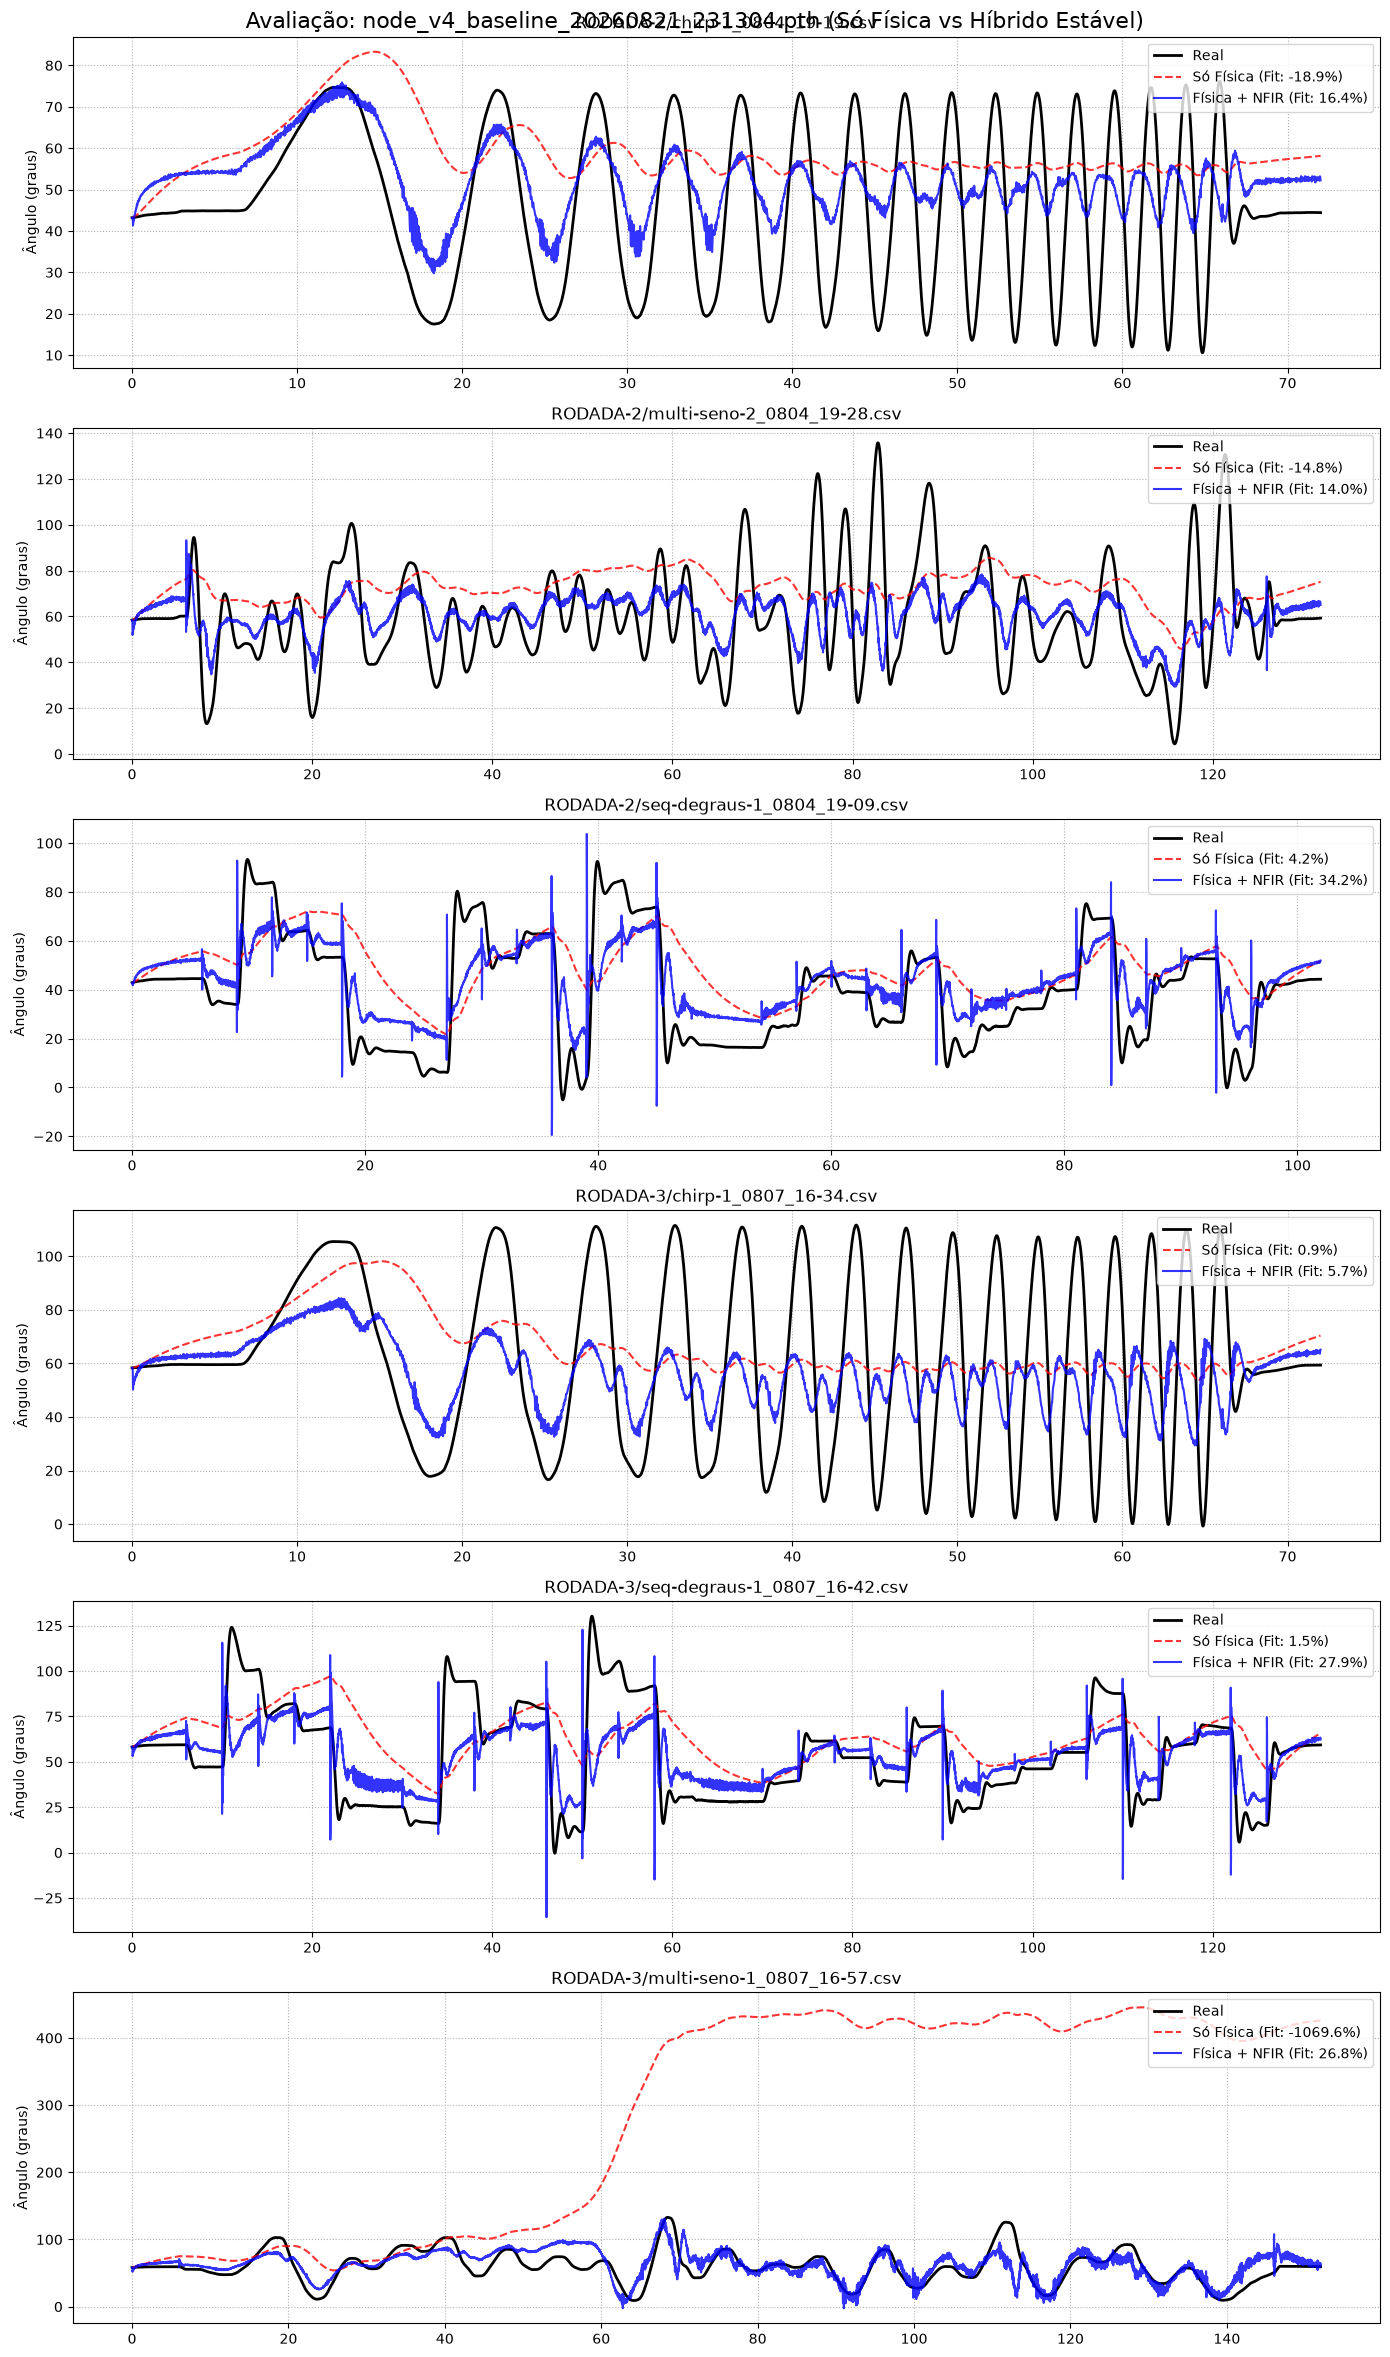


Iniciando Pipeline para: node_v4_asymmetric_20260822_105519.pth
1. Simulando ODE para Treino e Validação (gerando resíduos)...
2. Treinando o NFIR Polinomial (Estável) sobre os Resíduos...

Equação resultante:
e(k) = -0.006470 (bias)
       + 2.826868 * [v_ode(k-1)]
       - 2.822069 * [v_ode(k-0)]
       + 2.039370 * [u(k-1)]
       - 1.000505 * [y_ode(k-0)]
       - 0.071062 * [v_ode(k-0) * u(k-3)]
       - 0.001501 * [y_ode(k-0) * v_ode(k-1)]
       + 0.001499 * [y_ode(k-0) * v_ode(k-0)]
       + 0.001300 * [v_ode(k-0)^2]
       + 0.001188 * [y_ode(k-0) * u(k-3)]
       - 0.000441 * [y_ode(k-2) * u(k-1)]
       - 0.000140 * [y_ode(k-2) * u(k-2)]
       + 0.000000 * [y_ode(k-0)^2]

3. Gerando Gráficos Híbridos (Free-Run Cross-Session)...


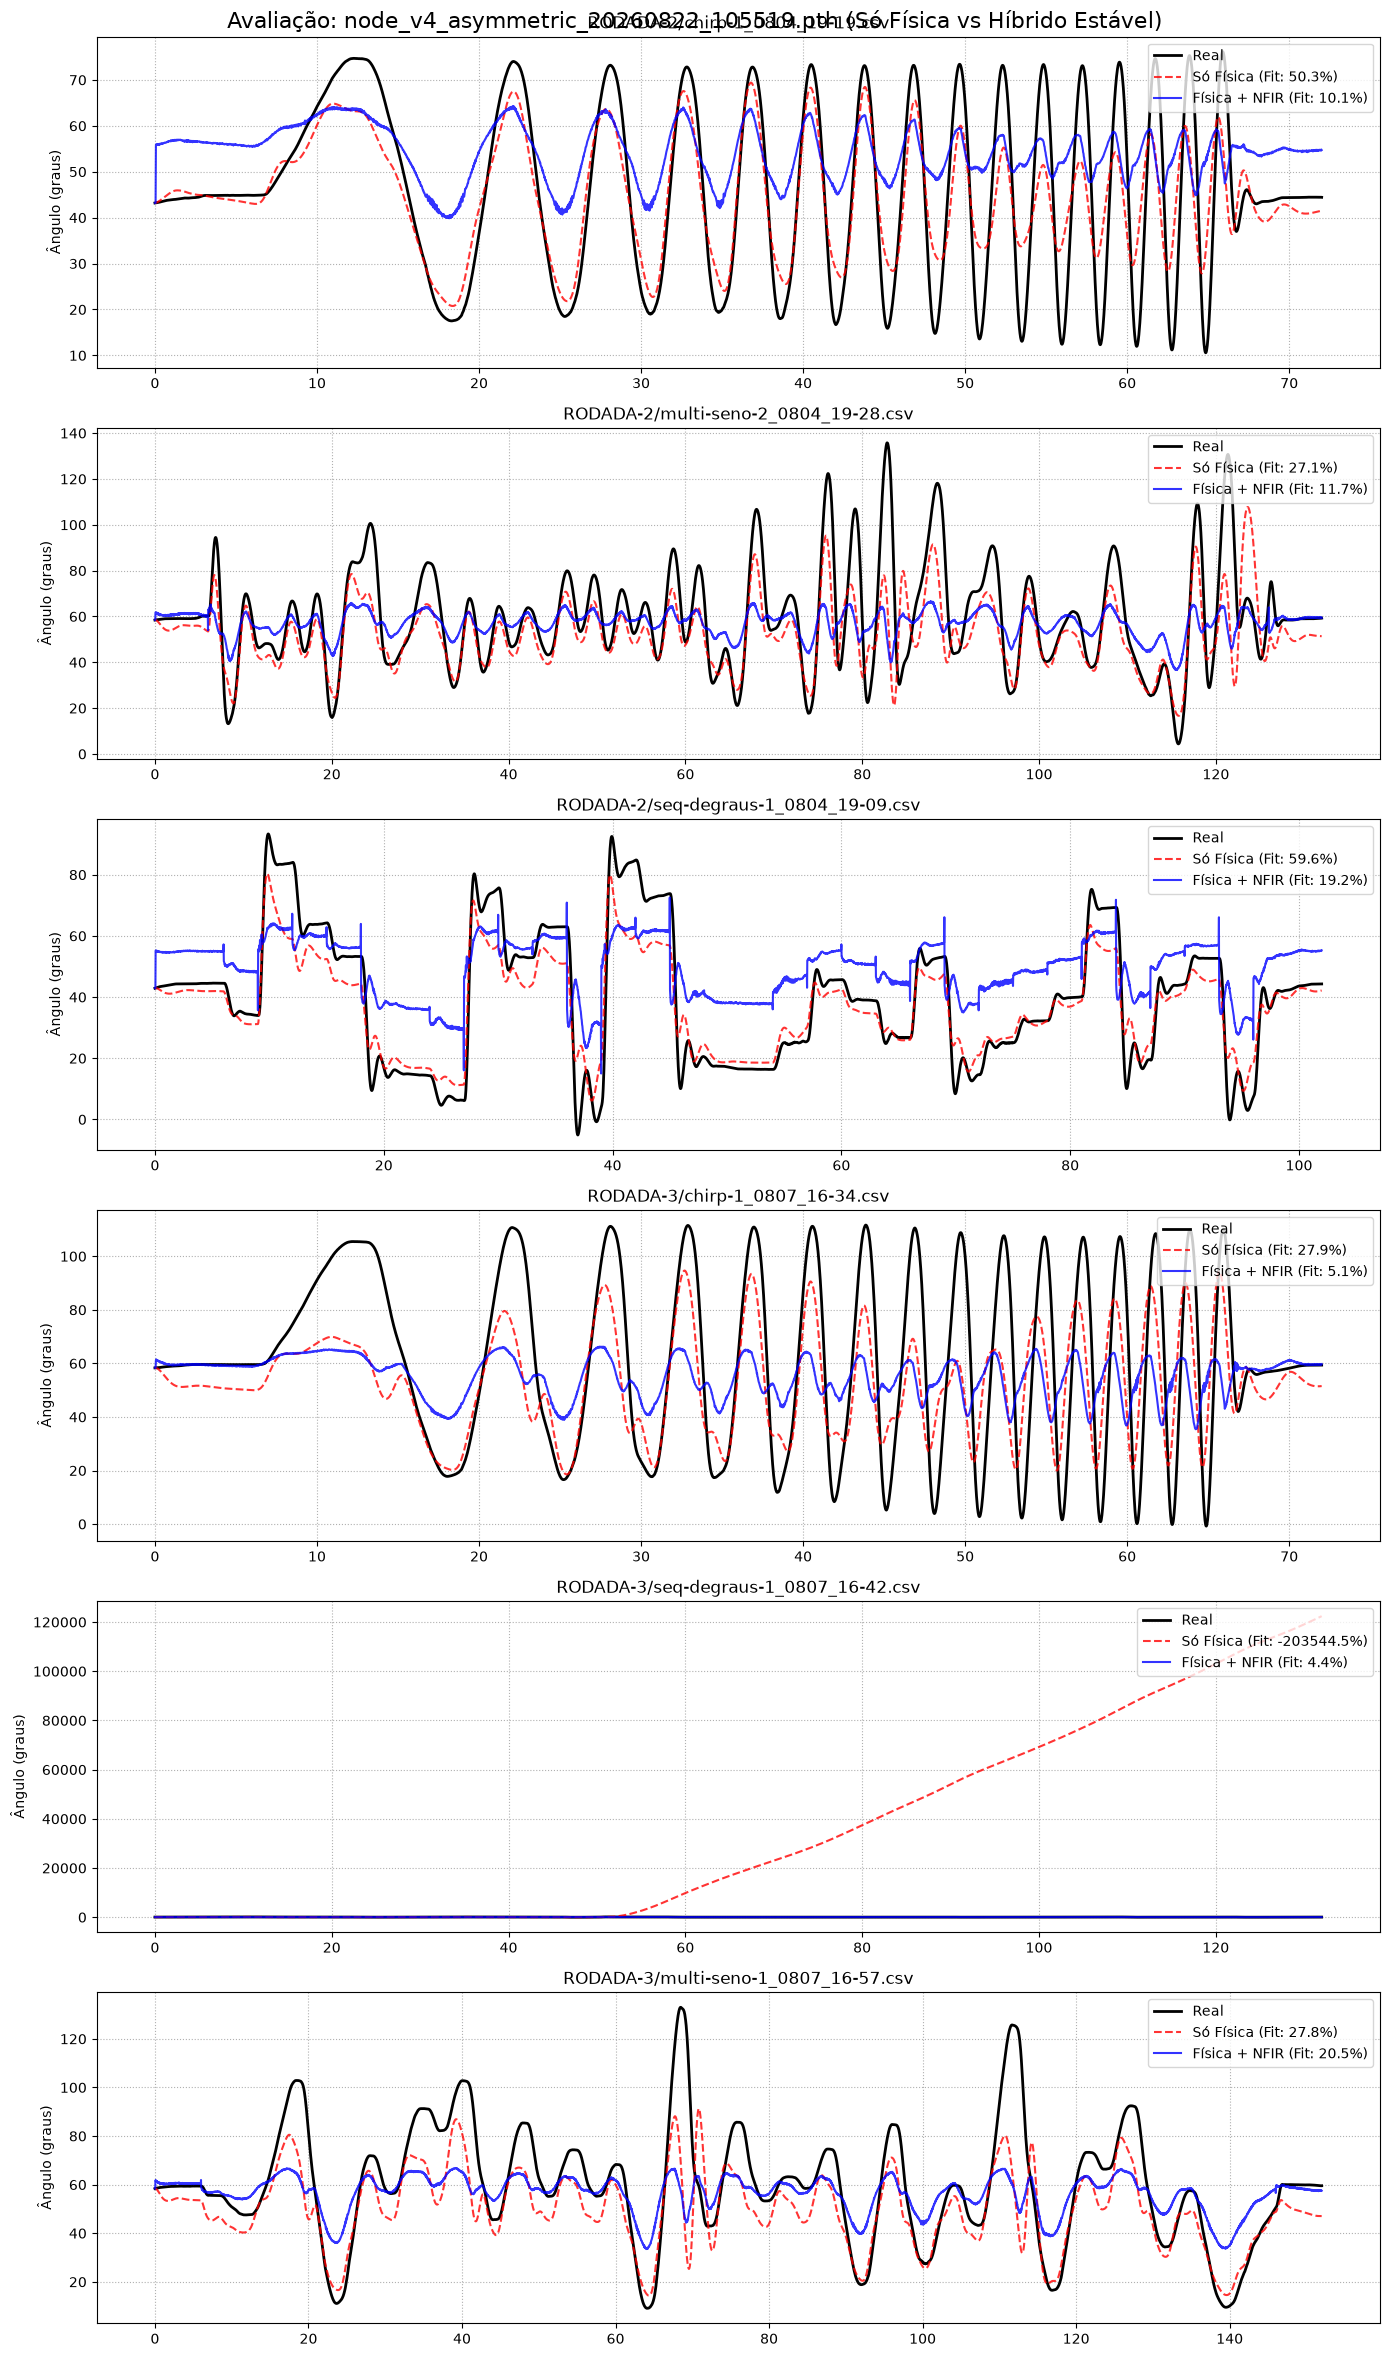

In [37]:
# %%
# 4. LOOP SOBRE OS MODELOS SELECIONADOS

model_dir = r'../modelos_salvos/RODADA-1'

modelos_para_testar = [
    'node_v4_baseline_20260821_231304.pth',
    'node_v4_asymmetric_20260822_105519.pth',
]

for model_name in modelos_para_testar:
    print(f"\n{'='*60}\nIniciando Pipeline para: {model_name}\n{'='*60}")
    model_path = os.path.join(model_dir, model_name)
    
    if 'baseline' in model_name.lower():
        base_model = node_v4.PhysicsODE_Baseline()
    elif 'asymmetric' in model_name.lower():
        base_model = node_v4.PhysicsODE_Asymmetric()
    elif 'hybrid' in model_name.lower():
        base_model = node_v4.PhysicsODE_Hybrid(hidden_dim=16)
    else:
        print(f"Aviso: Não foi possível determinar a arquitetura para {model_name}. Ignorando.")
        continue
        
    base_model.load_state_dict(torch.load(model_path, map_location=device))
    base_model.to(device)
    base_model.eval()
    
    print("1. Simulando ODE para Treino e Validação (gerando resíduos)...")
    gerar_residuos(base_model, train_datasets)
    gerar_residuos(base_model, val_datasets)
    
    print("2. Treinando o NFIR Polinomial (Estável) sobre os Resíduos...")
    # Usamos y_ode, v_ode e u para prever o erro
    nfir_resid = StableErrorNFIR(ny=3, nv=2, nu=3, degree=2, n_components=12)
    nfir_resid.fit(train_datasets)
    print("\nEquação resultante:")
    nfir_resid.print_equations()
    
    print("\n3. Gerando Gráficos Híbridos (Free-Run Cross-Session)...")
    avaliar_modelo_hibrido(val_datasets, f"Avaliação: {model_name} (Só Física vs Híbrido Estável)", nfir_resid)
